In [20]:
import pandas as pd
import matplotlib.pyplot as plg

In [24]:
df = pd.read_csv("../data/music_project_en.csv")

In [25]:
df.head(10)

,userID,Track,artist,genre,City,time,Day
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,20:28:33,Wednesday
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,14:07:09,Friday
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,20:58:07,Wednesday
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,08:37:09,Monday
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,08:34:34,Monday
5,842029A1,Chains,Obladaet,rusrap,Shelbyville,13:09:41,Friday
6,4CB90AA5,True,Roman Messer,dance,Springfield,13:00:07,Wednesday
7,F03E1C1F,Feeling This Way,Polina Griffith,dance,Springfield,20:47:49,Wednesday
8,8FA1D3BE,L’estate,Julia Dalia,ruspop,Springfield,09:17:40,Friday
9,E772D5C0,Pessimist,NaN,dance,Shelbyville,21:20:49,Wednesday


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0     userID  65079 non-null  object
 1   Track     63736 non-null  object
 2   artist    57512 non-null  object
 3   genre     63881 non-null  object
 4     City    65079 non-null  object
 5   time      65079 non-null  object
 6   Day       65079 non-null  object
dtypes: object(7)
memory usage: 3.5+ MB


## Data preprocessing

In [27]:
df.columns

Index(['  userID', 'Track', 'artist', 'genre', '  City  ', 'time', 'Day'], dtype='object')

In [28]:
# Columns names will be change in lower case
columns = df.columns
new_lowered = []

for i in columns:
    name_lowered = i.lower()
    new_lowered.append(name_lowered)

print(new_lowered)

['  userid', 'track', 'artist', 'genre', '  city  ', 'time', 'day']


In [29]:
# Same method will be applied for the spaces in the columns names
new_stripped = []

for i in new_lowered:
    name_stripped = i.strip()
    new_stripped.append(name_stripped)
    
print(new_stripped)
    

['userid', 'track', 'artist', 'genre', 'city', 'time', 'day']


In [30]:
# Changing name of userid to user_id
df.columns = new_stripped
df.rename(columns = {"userid" : "user_id"}, inplace = True)

In [ ]:
# The result of the columns
df.columns

Index(['user_id', 'track', 'artist', 'genre', 'city', 'time', 'day'], dtype='object')

## Missing values

In [32]:
df.isna().sum() 

user_id       0
track      1343
artist     7567
genre      1198
city          0
time          0
day           0
dtype: int64

In [33]:
# Loop through headers replacing missing values ​​with 'unknown'
columns_to_replace = ["track", "artist", "genre"]

for i in columns_to_replace:
    df[i].fillna("unknown", inplace = True)

/var/folders/9g/y9hgn7sd4_g82q2m37vjhtlw0000gn/T/ipykernel_99966/514716131.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna("unknown", inplace = True)


In [35]:
df.isna().sum()

user_id    0
track      0
artist     0
genre      0
city       0
time       0
day        0
dtype: int64

## Duplicated values

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.drop_duplicates(inplace = True)
df.reset_index(drop = True, inplace = True)

In [40]:
df.duplicated().sum()

np.int64(0)

## EDA

In [42]:
df.sort_values(by = "genre")["genre"].unique()

array(['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans',
       'alternative', 'ambient', 'americana', 'animated', 'anime',
       'arabesk', 'arabic', 'arena', 'argentinetango', 'art', 'audiobook',
       'avantgarde', 'axé', 'baile', 'balkan', 'beats', 'bigroom',
       'black', 'bluegrass', 'blues', 'bollywood', 'bossa', 'brazilian',
       'breakbeat', 'breaks', 'broadway', 'cantautori', 'cantopop',
       'canzone', 'caribbean', 'caucasian', 'celtic', 'chamber',
       'children', 'chill', 'chinese', 'choral', 'christian', 'christmas',
       'classical', 'classicmetal', 'club', 'colombian', 'comedy',
       'conjazz', 'contemporary', 'country', 'cuban', 'dance',
       'dancehall', 'dancepop', 'dark', 'death', 'deep', 'deutschrock',
       'deutschspr', 'dirty', 'disco', 'dnb', 'documentary', 'downbeat',
       'downtempo', 'drum', 'dub', 'dubstep', 'eastern', 'easy',
       'electronic', 'electropop', 'emo', 'entehno', 'epicmetal',
       'estrada', 'ethnic', 'eurofo

In [44]:
# Function to replace implicit duplicates
def replace_wrong_genres(df, column, wrong_genres, correct_genre):
    for i in wrong_genres:
        df[column] = df[column].replace(wrong_genres, correct_genre)
    
    return df

In [45]:
duplicates = ["hip", "hop", "hip-hop"]
genre = "hiphop"
df = replace_wrong_genres(df, "genre", duplicates, genre)

In [46]:
df.sort_values("genre")["genre"].unique()

array(['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans',
       'alternative', 'ambient', 'americana', 'animated', 'anime',
       'arabesk', 'arabic', 'arena', 'argentinetango', 'art', 'audiobook',
       'avantgarde', 'axé', 'baile', 'balkan', 'beats', 'bigroom',
       'black', 'bluegrass', 'blues', 'bollywood', 'bossa', 'brazilian',
       'breakbeat', 'breaks', 'broadway', 'cantautori', 'cantopop',
       'canzone', 'caribbean', 'caucasian', 'celtic', 'chamber',
       'children', 'chill', 'chinese', 'choral', 'christian', 'christmas',
       'classical', 'classicmetal', 'club', 'colombian', 'comedy',
       'conjazz', 'contemporary', 'country', 'cuban', 'dance',
       'dancehall', 'dancepop', 'dark', 'death', 'deep', 'deutschrock',
       'deutschspr', 'dirty', 'disco', 'dnb', 'documentary', 'downbeat',
       'downtempo', 'drum', 'dub', 'dubstep', 'eastern', 'easy',
       'electronic', 'electropop', 'emo', 'entehno', 'epicmetal',
       'estrada', 'ethnic', 'eurofo

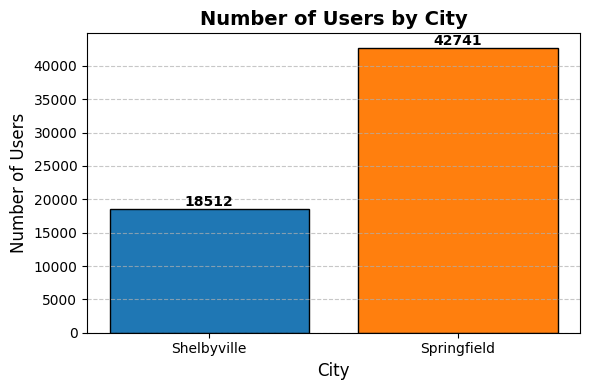

In [49]:
# Group by city: count unique users
city_counts = df.groupby(by="city")["user_id"].count()

# --- Bar chart ---
plt.figure(figsize=(6, 4))
plt.bar(city_counts.index, city_counts.values, color=["#1f77b4", "#ff7f0e"], edgecolor="black")

# Labels and title
plt.title("Number of Users by City", fontsize=14, weight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(city_counts.values):
    plt.text(i, v + max(city_counts.values)*0.01, str(v), ha='center', fontsize=10, weight='bold')

# Style and layout
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

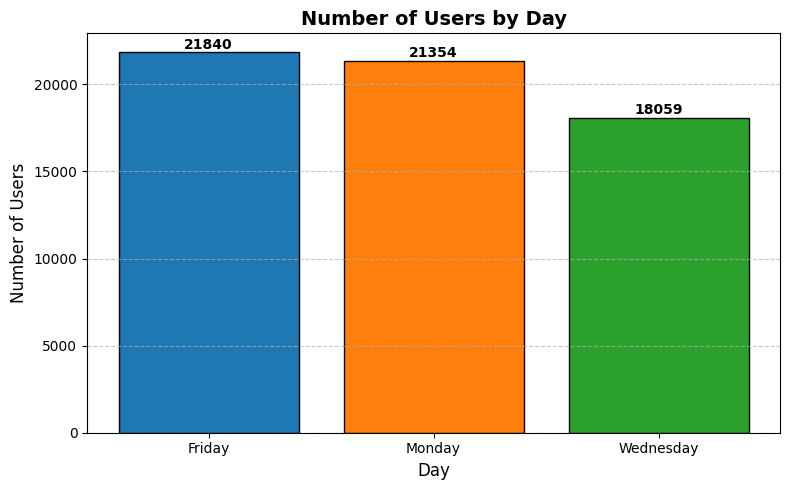

In [ ]:
import matplotlib.pyplot as plt

# Group by day: count users
day_counts = df.groupby(by="day")["user_id"].count()

# --- Custom color palette for each day ---
colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2"   # pink
]

# --- Bar chart ---
plt.figure(figsize=(8, 5))
plt.bar(day_counts.index, day_counts.values, color=colors[:len(day_counts)], edgecolor="black")

# Labels and title
plt.title("Number of Users by Day", fontsize=14, weight="bold")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# Add value labels above each bar
for i, v in enumerate(day_counts.values):
    plt.text(i, v + max(day_counts.values)*0.01, str(v), ha='center', fontsize=10, weight='bold')

# Style and layout
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [68]:
# Define the function number_tracks() with two parameters: day and city
def number_tracks(df, day, city):
    """
    Returns the number of users who listened to tracks
    on a specific day in a specific city.
    """

    # Filter rows where the value in the 'day' column matches the given day
    by_day = df[df["day"] == day]

    # Further filter rows where the value in the 'city' column matches the given city
    by_city = by_day[by_day["city"] == city]

    # Extract the 'user_id' column from the filtered table and count the entries
    final_users = by_city["user_id"].count()

    # Return the number of user_id values
    return final_users

## Top 10 Music Genres

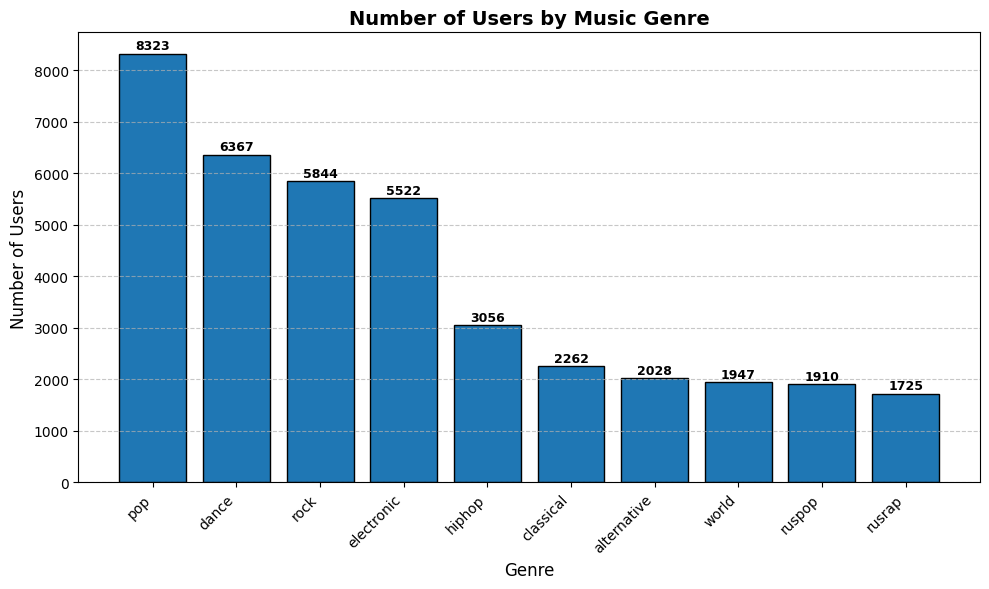

In [75]:
# Group by genre: count users
genre_counts = df.groupby(by="genre")["user_id"].count().sort_values(ascending=False).head(10)

# --- Bar chart ---
plt.figure(figsize=(10, 6))
plt.bar(genre_counts.index, genre_counts.values, color="#1f77b4", edgecolor="black")

# Labels and title
plt.title("Number of Users by Music Genre", fontsize=14, weight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# Rotate x labels for better readability
plt.xticks(rotation=45, ha="right")

# Add value labels on top of each bar
for i, v in enumerate(genre_counts.values):
    plt.text(i, v + max(genre_counts.values)*0.01, str(v), ha='center', fontsize=9, weight='bold')

# Style and layout
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Monday

In [60]:
print(f'The number of songs played in Springfield on Monday {number_tracks(df, "Monday", "Springfield")}')

The number of songs played in Springfield on Monday 15740


In [62]:
print(f'The number of songs played in Shelbyville on Monday {number_tracks(df, "Monday", "Shelbyville")}')

The number of songs played in Shelbyville on Monday 5614


### Wednesday

In [63]:
print(f'The number of songs played in Springfield on Wednesday {number_tracks(df, "Wednesday", "Springfield")}')

The number of songs played in Springfield on Wednesday 11056


In [64]:
print(f'The number of songs played in Shelbyville on Wednesday {number_tracks(df, "Wednesday", "Shelbyville")}')

The number of songs played in Shelbyville on Wednesday 7003


### Friday

In [66]:
print(f'The number of songs played in Springfield on Friday {number_tracks(df, "Friday", "Springfield")}')

The number of songs played in Springfield on Friday 15945


In [67]:
print(f'The number of songs played in Shelbyville on Friday {number_tracks(df, "Friday", "Shelbyville")}')

The number of songs played in Shelbyville on Friday 5895
